In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
input_folder = "/content/drive/MyDrive/Images"
output_folder = "/content/drive/MyDrive/sharpen_fundas_images"

In [4]:
os.makedirs(output_folder, exist_ok=True)

In [5]:
# Option 1
kernel = np.array([[0, 1, 0],
                   [1,-4, 1],
                   [0, 1, 0]])

In [ ]:
# Option 2
kernel = np.array([[1, 1, 1],
                   [1,-8, 1],
                   [1, 1, 1]])

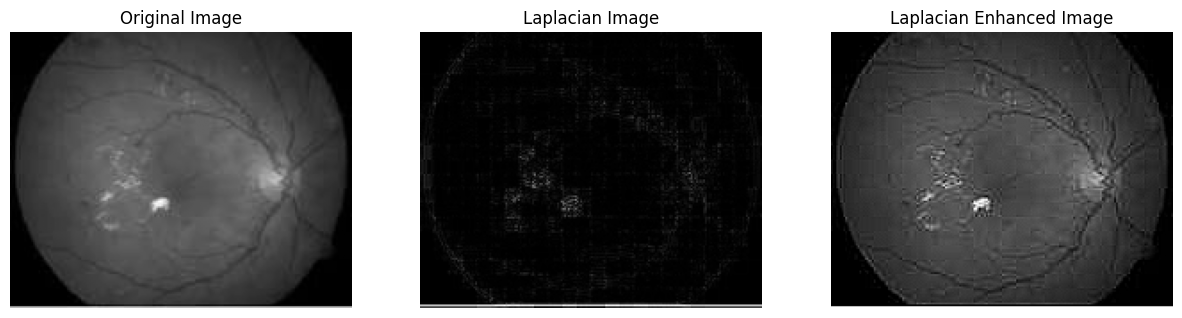

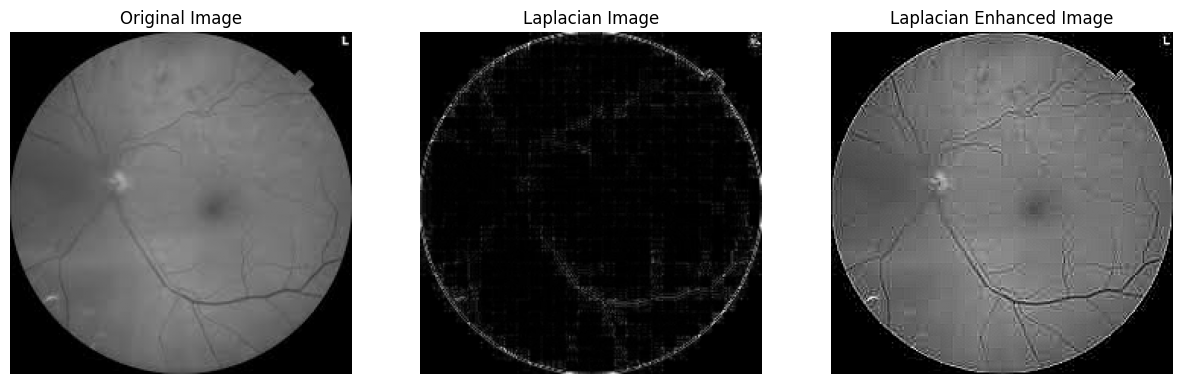

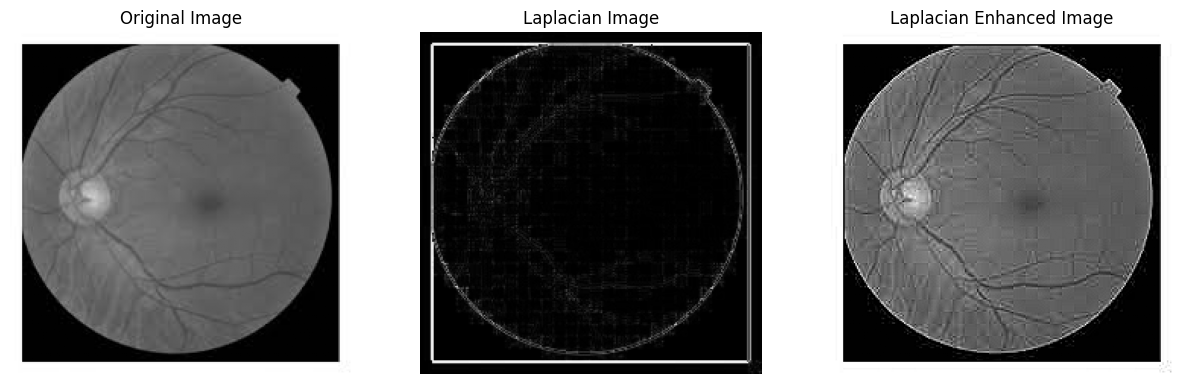

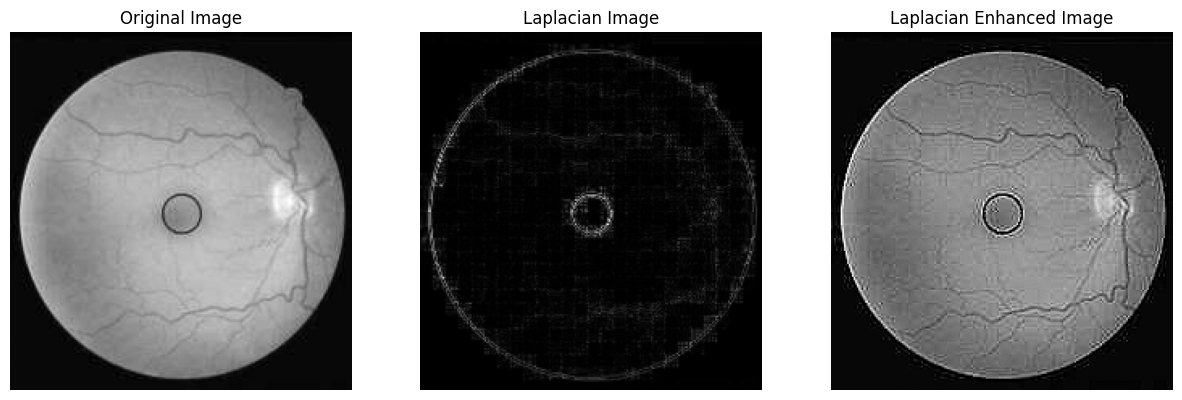

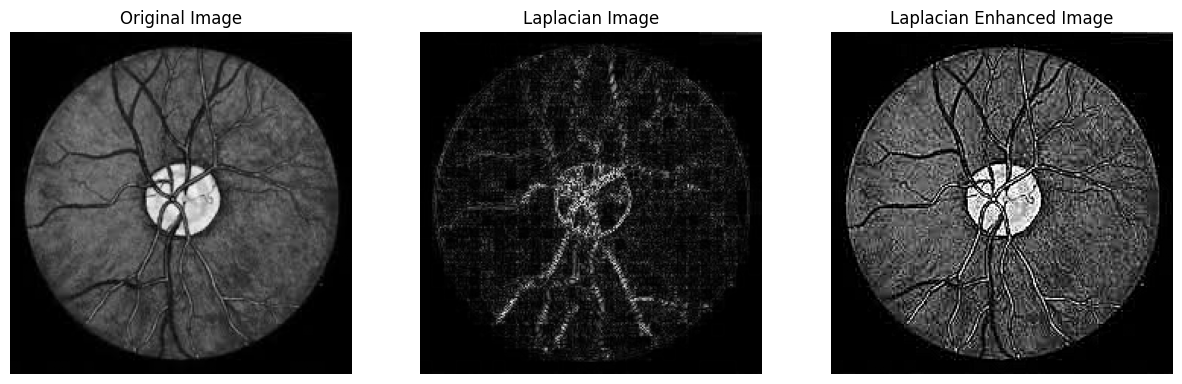

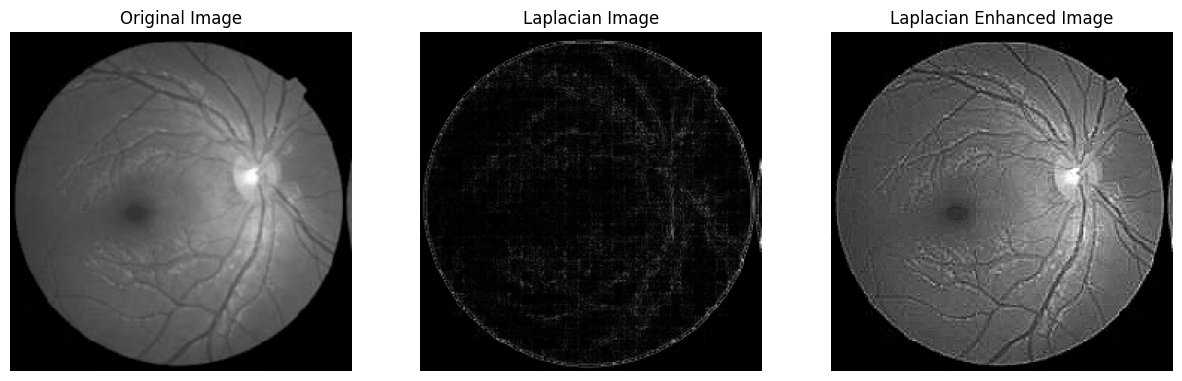

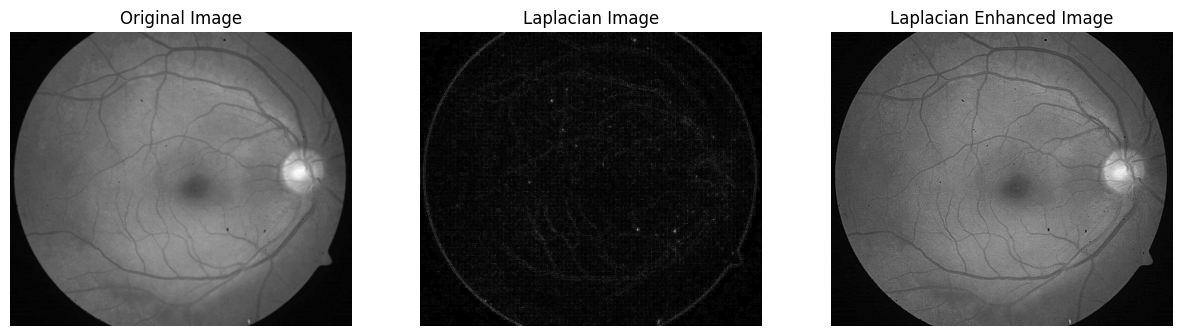

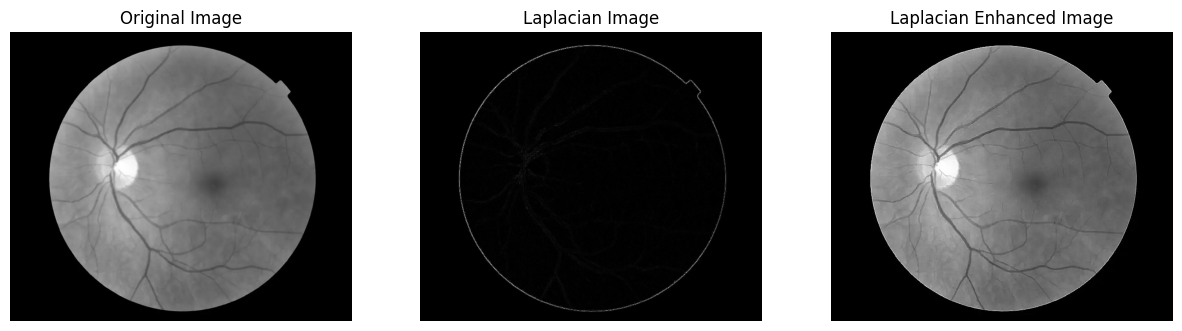

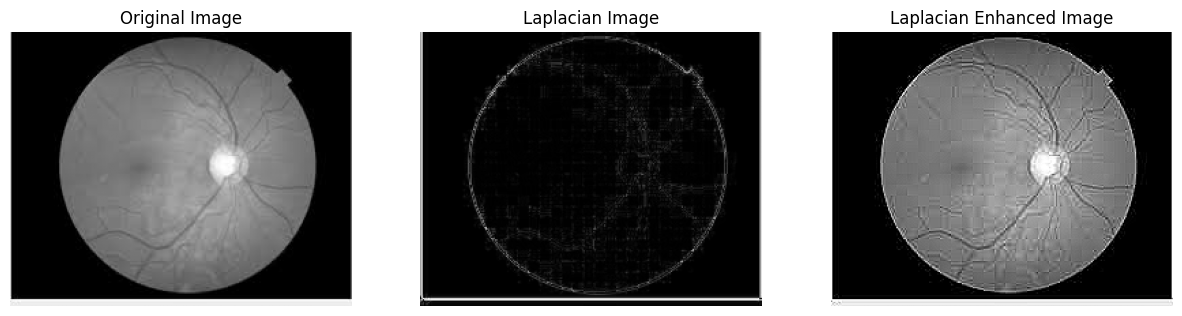

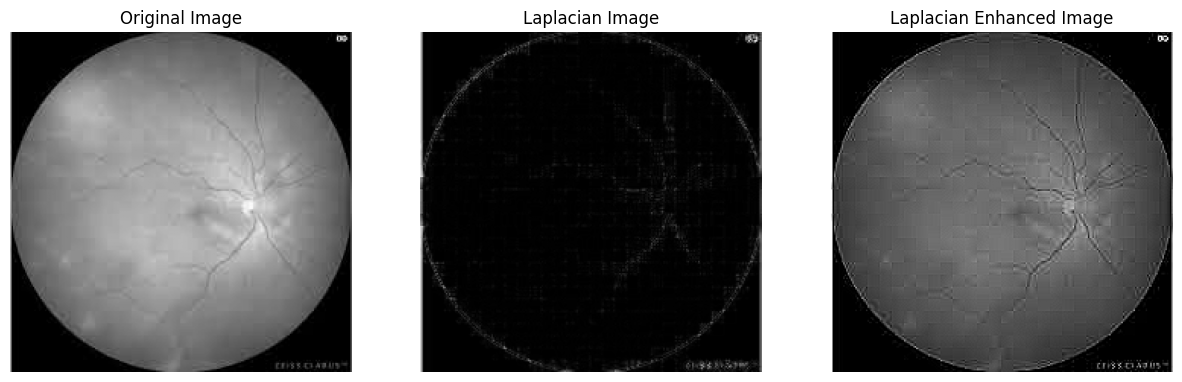

In [ ]:
image_files = os.listdir(input_folder)[:10]

for img_name in image_files:

    img_path = os.path.join(input_folder, img_name)
    img = cv2.imread(img_path, 0)   # grayscale

    if img is None:
        continue

    laplacian = cv2.filter2D(img, cv2.CV_64F, kernel)

    laplacian_display = np.uint8(np.absolute(laplacian))

    # Laplacian Enhancement
    enhanced = img - laplacian
    enhanced = np.clip(enhanced, 0, 255)
    enhanced = enhanced.astype(np.uint8)

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(img, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(laplacian_display, cmap='gray')
    plt.title("Laplacian Image")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(enhanced, cmap='gray')
    plt.title("Laplacian Enhanced Image")
    plt.axis('off')

    plt.show()


    # Save Enhanced Image
    save_path = os.path.join(output_folder, "enhanced_" + img_name)
    cv2.imwrite(save_path, enhanced)